# PV and Battery Sensitivity Analysis - Kalix, Sweden

This notebook explores the **Annual Savings** achieved across a range of PV and Battery sizing configurations, compared to a baseline of having no solar installation.

### Parameters Explored:
- **PV Power**: 10 kW to 22 kW (2 kW steps).
    - 10 kW fixed at 135° (South-East).
    - Residual capacity at 315° (North-West).
- **Battery Capacity**: 5 kWh to 20 kWh (5 kWh steps).
    - Max power fixed at 5 kW.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os

from solar.config import SimulationConfig, SolarStringConfig, BatteryConfig
from solar.simulation import run_simulation

# Constants from baseline study
PROCESSED_DIR = "../data/processed"
YEAR = "2025"
LAT = 65.916940
LON = 22.649684

## 1. Establish Baseline (No PV / No Battery)

We calculate the cost of electricity with zero hardware to determine the absolute savings of other configurations.

In [2]:
baseline_config = SimulationConfig(
    latitude=LAT, 
    longitude=LON,
    pv_strings=[],
    battery=None,
    return_timeseries=False
)

baseline_metrics = run_simulation(baseline_config, PROCESSED_DIR, YEAR)
baseline_cost = baseline_metrics["net_electricity_cost_sek"]

print(f"Baseline Annual Electricity Cost: {baseline_cost:,.0f} SEK")

Baseline Annual Electricity Cost: 8,711 SEK


## 2. Run Sensitivity Loop

We iterate through all combinations and calculate **Annual Savings = Baseline Cost - Configuration Cost**.

In [3]:
pv_powers = np.arange(10, 23, 2)     # [10, 12, 14, 16, 18, 20, 22]
bat_capacities = np.arange(5, 21, 5) # [5, 10, 15, 20]

results = []

# Add the [0, 0] baseline for visualization reference
results.append({
    "PV Power (kW)": 0,
    "Battery Capacity (kWh)": 0,
    "Net Electricity Cost (SEK)": baseline_cost,
    "Annual Savings (SEK)": 0.0
})

for pv_kw in pv_powers:
    for bat_kwh in bat_capacities:
        # Construct PV Strings: 10kW SE + Excess NW
        strings = [SolarStringConfig(capacity_kw=10.0, tilt=35, azimuth=135)]
        if pv_kw > 10:
            strings.append(SolarStringConfig(capacity_kw=pv_kw - 10.0, tilt=35, azimuth=315))
        
        # Construct Battery (fixed 5kW power)
        battery = BatteryConfig(
            capacity_kwh=float(bat_kwh), 
            max_power_kw=5.0,
            round_trip_efficiency=0.95,
            fcr_allocation_pct=0.0
        )
        
        config = SimulationConfig(
            latitude=LAT, longitude=LON,
            pv_strings=strings, battery=battery,
            return_timeseries=False
        )
        
        metrics = run_simulation(config, PROCESSED_DIR, YEAR)
        current_cost = metrics["net_electricity_cost_sek"]
        
        results.append({
            "PV Power (kW)": pv_kw,
            "Battery Capacity (kWh)": bat_kwh,
            "Net Electricity Cost (SEK)": current_cost,
            "Annual Savings (SEK)": baseline_cost - current_cost
        })

df_results = pd.DataFrame(results)

## 3. Configuration Savings Matrix

The matrix below shows the **Annual Savings (SEK)** for each configuration. Higher values (green) represent greater economic benefit.

In [4]:
# Filter out the 0,0 baseline for the pivot matrix to keep it clean
matrix_data = df_results[df_results["PV Power (kW)"] > 0]
matrix = matrix_data.pivot(index="PV Power (kW)", columns="Battery Capacity (kWh)", values="Annual Savings (SEK)")

styled_matrix = matrix.style.background_gradient(cmap="RdYlGn") \
                             .format("{:,.0f} SEK")

print("Annual Savings Matrix (SEK)")
display(styled_matrix)

Annual Savings Matrix (SEK)


Battery Capacity (kWh),5,10,15,20
PV Power (kW),,,,
10,"4,170 SEK","4,703 SEK","5,031 SEK","5,250 SEK"
12,"4,427 SEK","4,939 SEK","5,274 SEK","5,497 SEK"
14,"4,658 SEK","5,162 SEK","5,500 SEK","5,728 SEK"
16,"4,875 SEK","5,377 SEK","5,714 SEK","5,948 SEK"
18,"5,082 SEK","5,583 SEK","5,921 SEK","6,159 SEK"
20,"5,283 SEK","5,784 SEK","6,123 SEK","6,364 SEK"
22,"5,479 SEK","5,982 SEK","6,321 SEK","6,565 SEK"


## 4. Installation Price vs. Annual Savings

This plot shows the trade-off between the **Upfront Investment** (CAPEX) and the **Annual Savings** (ROI impact).

**Price Formulas:**
- PV Price: `2296 * PV_Power_kW + 18723` SEK (0 if PV=0)
- Battery Price: `2146 * Capacity_kWh + 21750` SEK (0 if Battery=0)

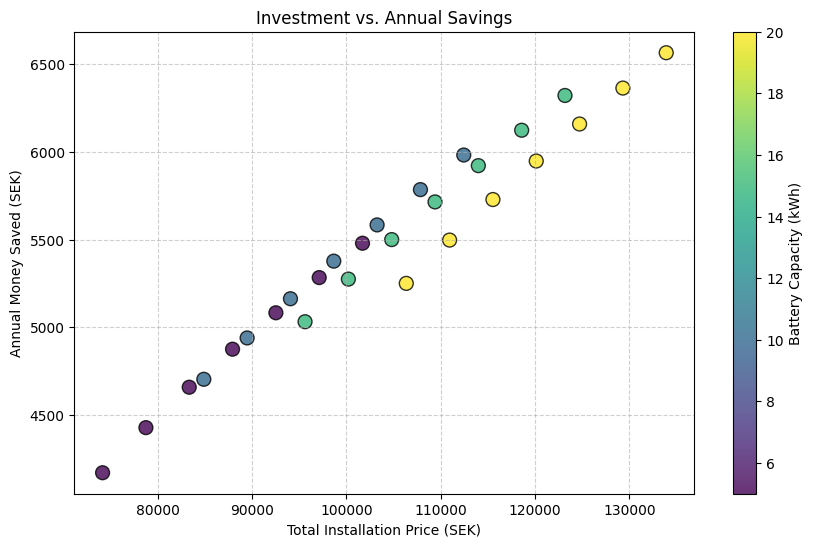

In [5]:
def calc_price(row):
    if row["PV Power (kW)"] == 0 and row["Battery Capacity (kWh)"] == 0:
        return 0.0
    pv_price = 2296 * row["PV Power (kW)"] + 18723
    bat_price = 2146 * row["Battery Capacity (kWh)"] + 21750
    return pv_price + bat_price

df_results["Total Installation Price (SEK)"] = df_results.apply(calc_price, axis=1)
no_zero = df_results["Total Installation Price (SEK)"] > 0

plt.figure(figsize=(10, 6))
plt.scatter(
    df_results["Total Installation Price (SEK)"][no_zero], 
    df_results["Annual Savings (SEK)"][no_zero], 
    c=df_results["Battery Capacity (kWh)"][no_zero], 
    cmap="viridis", 
    s=100, 
    edgecolors='k', 
    alpha=0.8
)
plt.colorbar(label="Battery Capacity (kWh)")
plt.xlabel("Total Installation Price (SEK)")
plt.ylabel("Annual Money Saved (SEK)")
plt.title("Investment vs. Annual Savings")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

### Observation
The plot identifies the "efficient frontier" where increasing investment yields the highest marginal savings. The [0,0] point represents the status quo.